# Cylinders under lateral and hydrostatic pressure: NASA/SP-8007-2020/REV 2

NASA, *Buckling of thin-walled circular cylinders*, NASA/SP-8007-2020/REV 2, NASA Langley Research Center, 2020, https://ntrs.nasa.gov/citations/20205011530.

Section *External Pressure*, simply supported cylinders of length $L$, radius $r$ and thickness $t$:

- lateral pressure, on the curved walls only, $N_y = p r$, Eqs. (19)-(20): $N_y = k_y \pi^2 D/L^2$, $k_y = \frac{1}{\beta^2}\left[(1 + \beta^2)^2 + \frac{12 \gamma^2 Z^2}{\pi^4 (1 + \beta^2)^2}\right]$, with $\beta = n L/(\pi r)$ and $Z = L^2 \sqrt{1 - \nu^2}/(r t)$, from Batdorf;
- hydrostatic pressure, also on the ends, $N_x = p r/2$, Eqs. (21)-(22): $\beta^2$ before the bracket replaced by $\beta^2 + 1/2$;
- long cylinders, Eq. (66): $p_{cr} = 3 D/r^3$; moderately long cylinders, $\gamma Z > 100$, Eq. (23): $k_y = k_p = 1.04\sqrt{\gamma Z}$;

with $\gamma = 1$ here, i.e. without the knockdown factor. Batdorf's equation is the Donnell solution with a pressure of constant direction: it is compared with panels with the Donnell and Sanders kinematics and the constant directional and follower pressures. The data of Figure 4-3, the curves of $k_y$ and $k_p$ against $Z$, are recomputed from the equations.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import follower_utils as fu
from follower_utils import val, fmt, pct, markdown_table

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'

from structsolve import lb

## panels model

`val.cylinder_shell`: half of the length and half of the circumference, with symmetry planes at the mid-length and at $\theta = 0, \pi$, and shear-diaphragm ends, $v = w = 0$, which contains the modes $\sin(\pi x/L)\cos(n\theta)$ of any $n$. The prestress is the membrane state of the pressure, `Shell.Nyy` and `Shell.Nxx`, as in Batdorf's analysis, and the follower load stiffness is `calc_kCfollower`. $r/t = 100$, $\nu = 0.3$, $L/r$ from 0.3 to 30 (Z from 9 to $8.6 \times 10^4$).

In [2]:
E, NU = val.E, val.NU
R, T = 1., 0.01
D = E*T**3/(12*(1 - NU**2))
LRS = [0.3, 0.5, 1., 2., 3., 5., 8., 12., 20., 30.]


def Z_of(L):
    return L**2*np.sqrt(1 - NU**2)/(R*T)


def batdorf_k(Z, prestate, beta=None):
    fac = 0. if prestate == 'lateral' else 0.5
    if beta is None:
        beta = np.logspace(-2, 2, 4001)
    k = ((1 + beta**2)**2 + 12*Z**2/(np.pi**4*(1 + beta**2)**2))/(beta**2 + fac)
    return k.min()


def compute():
    res = {}
    for LR in LRS:
        L = LR*R
        for prestate in ('lateral', 'hydrostatic'):
            out = {}
            for model in ('cylshell_clpt_donnell', 'cylshell_clpt_sanders'):
                s = val.cylinder_shell(model, L, R, T, m=8, n=30)
                for follower in (False, True):
                    s.clear_loads()
                    s.Nxx = 0. if prestate == 'lateral' else -R/2
                    s.Nyy = -R
                    s.add_pressure_load(-1., cte=False, follower=follower)
                    K = s.calc_kG()
                    if follower:
                        K = K + s.calc_kCfollower()
                    lam = float(np.real(lb(s.calc_kC(), K, silent=True, num_eigvalues=4)[0][0]))
                    out['%s %s' % (model.split('_')[2], 'follower' if follower else 'dead')] = lam
            res['%g %s' % (LR, prestate)] = out
    return res


res = fu.run_or_load(os.path.join(RESULTS, 'nasa_sp8007_external_pressure.json'), compute, rerun=RERUN)

In [3]:
for prestate in ('lateral', 'hydrostatic'):
    rows = []
    for LR in LRS:
        L = LR*R
        Z = Z_of(L)
        pb = val.batdorf_lateral_pressure(L, R, T, E, NU, prestate)
        r = res['%g %s' % (LR, prestate)]
        rows.append(['%g' % LR, '%.0f' % Z, '%.2f' % (batdorf_k(Z, prestate)), '%.2f' % (pb*R*L**2/(np.pi**2*D)),
                     '%.4g' % (pb*R**3/D)]
                    + ['%.4g (%+.2f%%)' % (r[m]*R**3/D, pct(r[m], pb)) for m in
                       ('donnell dead', 'donnell follower', 'sanders dead', 'sanders follower')])
    display(Markdown('**%s pressure**, $p r^3/D$, differences to Batdorf with integer $n$' % prestate))
    display(Markdown(markdown_table(['$L/r$', '$Z$', '$k$ Batdorf (continuous $\\beta$)', '$k$ Batdorf (integer $n$)',
                                     'Batdorf', 'panels Donnell, dead', 'panels Donnell, follower',
                                     'panels Sanders, dead', 'panels Sanders, follower'], rows)))

**lateral pressure**, $p r^3/D$, differences to Batdorf with integer $n$

| $L/r$ | $Z$ | $k$ Batdorf (continuous $\beta$) | $k$ Batdorf (integer $n$) | Batdorf | panels Donnell, dead | panels Donnell, follower | panels Sanders, dead | panels Sanders, follower |
|---|---|---|---|---|---|---|---|---|
| 0.3 | 9 | 4.99 | 5.00 | 548.4 | 548.4 (+0.00%) | 547 (-0.25%) | 550.2 (+0.34%) | 548.8 (+0.08%) |
| 0.5 | 24 | 6.75 | 6.77 | 267.5 | 267.5 (+0.00%) | 266 (-0.54%) | 268.9 (+0.54%) | 267.4 (-0.01%) |
| 1 | 95 | 11.65 | 11.72 | 115.7 | 115.7 (+0.00%) | 114.3 (-1.26%) | 116.9 (+1.01%) | 115.4 (-0.27%) |
| 2 | 382 | 21.72 | 21.72 | 53.58 | 53.58 (+0.00%) | 52.26 (-2.47%) | 54.38 (+1.48%) | 53 (-1.08%) |
| 3 | 859 | 31.84 | 31.87 | 34.95 | 34.95 (-0.00%) | 33.69 (-3.63%) | 35.65 (+2.00%) | 34.31 (-1.84%) |
| 5 | 2385 | 52.13 | 52.58 | 20.76 | 20.76 (-0.00%) | 19.57 (-5.70%) | 21.32 (+2.73%) | 20.04 (-3.47%) |
| 8 | 6105 | 82.58 | 82.71 | 12.75 | 12.75 (-0.00%) | 11.51 (-9.79%) | 13.69 (+7.31%) | 12.2 (-4.33%) |
| 12 | 13737 | 123.19 | 143.43 | 9.831 | 9.831 (-0.00%) | 8.857 (-9.91%) | 10.02 (+1.93%) | 8.919 (-9.27%) |
| 20 | 38158 | 204.42 | 205.71 | 5.076 | 5.076 (-0.00%) | 4.067 (-19.86%) | 5.881 (+15.87%) | 4.423 (-12.85%) |
| 30 | 85855 | 305.95 | 385.37 | 4.226 | 4.226 (-0.00%) | 3.383 (-19.94%) | 4.387 (+3.81%) | 3.295 (-22.04%) |

**hydrostatic pressure**, $p r^3/D$, differences to Batdorf with integer $n$

| $L/r$ | $Z$ | $k$ Batdorf (continuous $\beta$) | $k$ Batdorf (integer $n$) | Batdorf | panels Donnell, dead | panels Donnell, follower | panels Sanders, dead | panels Sanders, follower |
|---|---|---|---|---|---|---|---|---|
| 0.3 | 9 | 3.85 | 3.85 | 422.5 | 422.5 (+0.00%) | 421.6 (-0.20%) | 423.2 (+0.18%) | 422.4 (-0.02%) |
| 0.5 | 24 | 5.82 | 5.82 | 229.9 | 229.9 (+0.00%) | 228.9 (-0.47%) | 230.6 (+0.30%) | 229.6 (-0.17%) |
| 1 | 95 | 10.86 | 10.89 | 107.4 | 107.4 (+0.00%) | 106.2 (-1.17%) | 108.3 (+0.78%) | 107 (-0.41%) |
| 2 | 382 | 20.99 | 21.00 | 51.81 | 51.81 (+0.00%) | 50.57 (-2.39%) | 52.47 (+1.29%) | 51.19 (-1.19%) |
| 3 | 859 | 31.14 | 31.19 | 34.2 | 34.2 (-0.00%) | 32.99 (-3.55%) | 34.82 (+1.81%) | 33.54 (-1.94%) |
| 5 | 2385 | 51.44 | 51.94 | 20.5 | 20.5 (-0.00%) | 19.35 (-5.63%) | 21.03 (+2.56%) | 19.78 (-3.55%) |
| 8 | 6105 | 81.90 | 82.00 | 12.65 | 12.65 (-0.00%) | 11.42 (-9.71%) | 13.54 (+7.07%) | 12.09 (-4.43%) |
| 12 | 13737 | 122.52 | 142.89 | 9.793 | 9.793 (-0.00%) | 8.827 (-9.87%) | 9.973 (+1.83%) | 8.881 (-9.32%) |
| 20 | 38158 | 203.74 | 205.07 | 5.06 | 5.06 (-0.00%) | 4.057 (-19.81%) | 5.849 (+15.59%) | 4.405 (-12.94%) |
| 30 | 85855 | 305.28 | 384.84 | 4.22 | 4.22 (-0.00%) | 3.38 (-19.92%) | 4.377 (+3.70%) | 3.289 (-22.08%) |

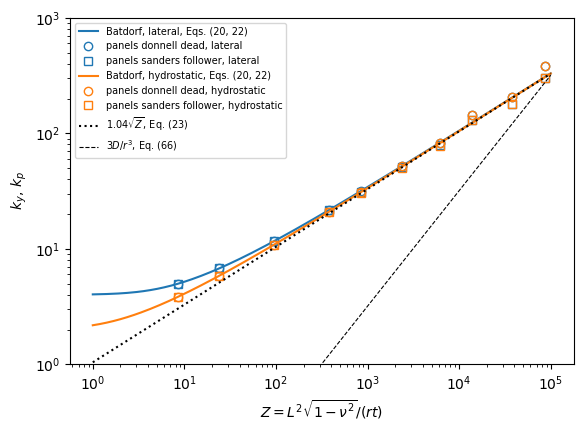

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
Zs = np.logspace(0, 5, 200)
for prestate, st in (('lateral', dict(color='C0')), ('hydrostatic', dict(color='C1'))):
    ax.loglog(Zs, [batdorf_k(Z, prestate) for Z in Zs], label='Batdorf, %s, Eqs. (20, 22)' % prestate, **st)
    for m, mk in (('donnell dead', 'o'), ('sanders follower', 's')):
        k = [res['%g %s' % (LR, prestate)][m]*R*(LR*R)**2/(np.pi**2*D) for LR in LRS]
        ax.loglog([Z_of(LR*R) for LR in LRS], k, mk, mfc='none', label='panels %s, %s' % (m, prestate), **st)
ax.loglog(Zs, 1.04*np.sqrt(Zs), 'k:', label='$1.04\\sqrt{Z}$, Eq. (23)')
ax.loglog(Zs, 3*Zs/(np.pi**2*np.sqrt(1 - NU**2))*T/R, 'k--', lw=0.8, label='$3D/r^3$, Eq. (66)')
ax.set_xlabel('$Z = L^2\\sqrt{1 - \\nu^2}/(r t)$')
ax.set_ylabel('$k_y$, $k_p$')
ax.set_ylim(1, 1e3)
ax.legend(fontsize=7)

## Discussion

- **Batdorf's equation** with the integer circumferential wave numbers is the Donnell solution of panels with the constant directional pressure, to the discretization error of panels, for the lateral and hydrostatic pressures and all lengths; with a continuous $\beta$ it is a lower bound, as in Figure 4-3 of SP-8007-2020/REV 2.
- **Follower pressure.** The follower load lowers the critical pressure, by 0.1% to 1% for the short cylinders, with many circumferential waves, up to the $n = 2$ limit of long cylinders, where it is 3/4 of the constant directional load with Sanders' kinematics (3.30 against 4.39 for $L/r = 30$): the long-cylinder limit $3D/r^3$ of Eq. (66) is the follower (hydrostatic) value, which the Sanders model of panels approaches, 3.29 for $L/r = 30$, whereas Batdorf's equation, with the constant directional load and Donnell's kinematics, tends to $4D/r^3$ (4.23 for $L/r = 30$).
- **Kinematics.** Donnell's and Sanders' kinematics agree within about 1% for the short cylinders and differ by up to 10-20% for the long ones, with few circumferential waves, the known limitation of Donnell's theory for low $n$; the sign of the difference changes with the wave number of the critical mode, and in the $n = 2$ limit the follower load gives $16/5$ with Donnell's kinematics against 3 with Sanders'.